* DSC540
* Milestone 5
* Dan Morrow

## Project Subject Area:
What Determines the Success of a Movie?

This project analyzes movie data to better understand how factors such as budget, genre, and popularity influence the overall success of a movie. This will be done by combining multiple data sources to explore relationships between ratings, revenue, and audience engagement.

## Milestone 5: Merging, Storing, and Visualizing Movie Data

In this milestone, the cleaned flat file, website, and API datasets are brought together and stored in a SQLite database. Each dataset will be loaded as its own table, then SQL joins will be used to create a consolidated dataset for analysis.

After the datasets are merged, five visualizations will be created to explore relationships between movie budget, revenue, popularity, ratings, genres, and box office performance.

In [1]:
#Import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import requests
from io import StringIO
import ast

#### Load Cleaned Flat File Dataset from Milestone 2

In this step, the TMDb flat file dataset is loaded and the same cleaning steps from Milestone 2 are applied. This creates the cleaned flat file dataset that will later be stored as a SQLite table.

In [2]:
#Load cleaned flat file dataset from home folder
df_flat = pd.read_csv("../cleaned_flat_movies.csv")

#Output
df_flat.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,release_year
0,237000000,"Action, Adventure, Fantasy, Science Fiction",19995,"culture clash, future, space war, space colony...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,2009
1,300000000,"Adventure, Fantasy, Action",285,"ocean, drug abuse, exotic island, east india t...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates Of The Caribbean: At World'S End,6.9,4500,2007
2,245000000,"Action, Adventure, Crime",206647,"spy, based on novel, secret agent, sequel, mi6...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,2015
3,250000000,"Action, Crime, Drama, Thriller",49026,"dc comics, crime fighter, terrorist, secret id...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,2012
4,260000000,"Action, Adventure, Science Fiction",49529,"based on novel, mars, medallion, space travel,...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,2012


#### Load Cleaned Website Dataset from Milestone 3

In this step, the cleaned website dataset from Milestone 3 is loaded into the notebook. This dataset contains movie information collected and transformed from website data sources.

Output: Displays the cleaned website dataset that will later be stored as a SQLite table.

In [3]:
#Load cleaned website dataset
df_website = pd.read_csv("cleaned_website_movies.csv")

#Output
df_website.head()

,rank,peak,title,worldwide_gross,year
0,1,1,Avatar,"$2,923,710,708",2009
1,2,1,Avengers: Endgame,"$2,797,501,328",2019
2,3,3,Avatar: The Way of Water,"$2,334,484,620",2022
3,4,1,Titanic,"$2,257,906,828",1997
4,5,5,Ne Zha 2,"$2,215,690,000",2025


#### Load Cleaned API Dataset from Milestone 4

In this step, the cleaned API dataset from Milestone 4 is loaded into the notebook. This dataset contains movie information retrieved and cleaned from the TMDb API source. Loading the cleaned API dataset prepares it for storage in SQLite and later merging with the other project datasets.

Output: Displays the cleaned API dataset that will later be stored as a SQLite table.

In [4]:
#Load cleaned API dataset
df_api_final = pd.read_csv("cleaned_api_movies.csv")

#Output
df_api_final.head()

,id,title,popularity,vote_average,vote_count,release_date,genre_ids,original_language,genre_names,release_year
0,1439930,The Punisher: One Last Kill,610.8006,8.600,733,2026-05-12,"[28, 18, 80]",EN,"Action, Drama, Crime",2026
1,687163,Project Hail Mary,445.9974,8.555,3311,2026-03-15,"[878, 12]",EN,"Science Fiction, Adventure",2026
2,1007757,Swapped,396.9951,8.987,1044,2026-05-01,"[16, 10751, 12, 14]",EN,"Animation, Family, Adventure, Fantasy",2026
3,1226863,The Super Mario Galaxy Movie,326.3666,6.696,864,2026-04-01,"[10751, 35, 12, 14, 16]",EN,"Family, Comedy, Adventure, Fantasy, Animation",2026
4,350,The Devil Wears Prada,286.9169,7.410,13427,2006-06-29,"[18, 35]",EN,"Drama, Comedy",2006


#### Connect to SQLite Database

In this step, a connection to a SQLite database is created for storing the cleaned movie datasets. SQLite is used to organize each dataset into its own table before joining them together for analysis and visualization.

Output: Confirms the database connection was successfully created.

In [5]:
#Import sqlite3 library
import sqlite3

#Create SQLite database connection
conn = sqlite3.connect("movies_project.db")

#Create cursor object
cursor = conn.cursor()

#Output
print("Database connection created successfully.")

Database connection created successfully.


#### Store Cleaned Datasets in SQLite Tables

In this step, each cleaned movie dataset is stored inside the SQLite database as its own table. Separating the datasets into individual tables allows them to later be merged together using SQL joins for analysis and visualization.

Output: Confirms that the datasets were successfully stored as SQLite tables.

In [6]:
#Store flat file dataset as SQLite table
df_flat.to_sql("movies_flat", conn, if_exists="replace", index=False)

#Store website dataset as SQLite table
df_website.to_sql("movies_website", conn, if_exists="replace", index=False)

#Store API dataset as SQLite table
df_api_final.to_sql("movies_api", conn, if_exists="replace", index=False)

#Output
print("Datasets stored successfully in SQLite database.")

Datasets stored successfully in SQLite database.


#### Merge Datasets Using SQL Join

In this step, the cleaned datasets are merged together using SQL joins within SQLite. The movie title and release year fields are used to combine related movie information across the flat file, website, and API datasets into one consolidated dataset for analysis.

Output: Shows the first several rows of the consolidated movie dataset after successfully joining the flat file, website, and API datasets using SQL joins.

In [7]:
#SQL query to merge datasets
query = """
SELECT
    f.id,
    f.title,
    f.budget,
    f.revenue,
    f.genres,
    f.release_year,
    w.worldwide_gross,
    a.popularity,
    a.vote_average AS api_vote_average,
    a.vote_count,
    a.genre_names
FROM movies_flat f
LEFT JOIN movies_website w
    ON f.title = w.title
    AND f.release_year = w.year
LEFT JOIN movies_api a
    ON f.id = a.id
"""

#Create merged dataset
df_merged = pd.read_sql_query(query, conn)

#Output
df_merged.head()

,id,title,budget,revenue,genres,release_year,worldwide_gross,popularity,api_vote_average,vote_count,genre_names
0,19995,Avatar,237000000,2787965087,"Action, Adventure, Fantasy, Science Fiction",2009,"$2,923,710,708",26.3883,7.604,33925.0,"Science Fiction, Action, Adventure"
1,285,Pirates Of The Caribbean: At World'S End,300000000,961000000,"Adventure, Fantasy, Action",2007,NaN,NaN,NaN,NaN,NaN
2,206647,Spectre,245000000,880674609,"Action, Adventure, Crime",2015,NaN,NaN,NaN,NaN,NaN
3,49026,The Dark Knight Rises,250000000,1084939099,"Action, Crime, Drama, Thriller",2012,"$1,081,169,825",NaN,NaN,NaN,NaN
4,49529,John Carter,260000000,284139100,"Action, Adventure, Science Fiction",2012,NaN,NaN,NaN,NaN,NaN


#### Check Merged Dataset Information

In this step, the structure of the consolidated movie dataset is reviewed to confirm that the SQL joins were successful and the expected columns from each dataset are present. Reviewing the dataset information also helps identify missing values and verify data types before creating visualizations.

Output: Shows the merged dataset structure, including column names, data types, and non-null counts. The output confirms that the flat file dataset contains the most complete movie records, while the website and API datasets only matched a subset of movies during the SQL joins.

In [8]:
#Output merged dataset information
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 4799 entries, 0 to 4798
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4799 non-null   int64  
 1   title             4799 non-null   str    
 2   budget            4799 non-null   int64  
 3   revenue           4799 non-null   int64  
 4   genres            4772 non-null   str    
 5   release_year      4799 non-null   int64  
 6   worldwide_gross   12 non-null     str    
 7   popularity        44 non-null     float64
 8   api_vote_average  44 non-null     float64
 9   vote_count        44 non-null     float64
 10  genre_names       44 non-null     str    
dtypes: float64(3), int64(4), str(4)
memory usage: 412.5 KB


#### Visualization 1: Movie Budget vs Revenue

This visualization explores the relationship between movie production budgets and worldwide revenues using the merged movie dataset. Examining this relationship helps identify whether larger production investments are generally associated with stronger financial performance.

Output: The scatter plot shows a positive relationship between movie budgets and revenues, although substantial variability exists across films. Higher-budget movies often generated larger revenues, but several expensive films still underperformed financially. This suggests that while production budget may influence financial success, it does not guarantee profitability on its own.

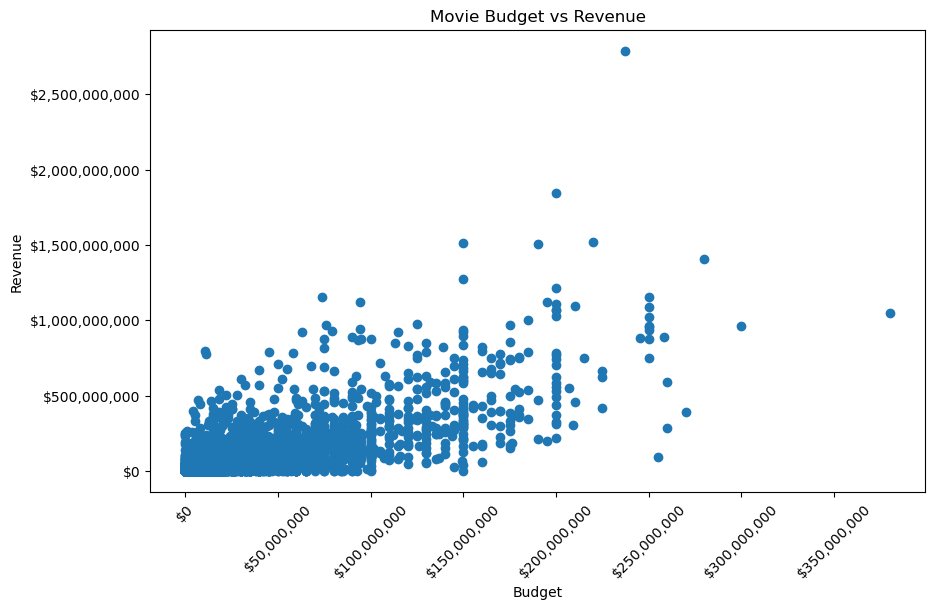

In [9]:
#Import matplotlib ticker formatter
from matplotlib.ticker import FuncFormatter

#Create scatter plot for budget vs revenue
plt.figure(figsize=(10,6))
plt.scatter(df_merged['budget'], df_merged['revenue'])

#Format axis labels as dollar values
formatter = FuncFormatter(lambda x, p: f'${x:,.0f}')

plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

#Rotate x-axis labels
plt.xticks(rotation=45)

#Add chart labels and title
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Movie Budget vs Revenue")

#Output
plt.show()

#### Visualization 2: Top Movies by Worldwide Gross

This visualization identifies the movies with the highest worldwide gross revenues within the merged dataset. Comparing the top-performing films helps illustrate the uneven distribution of financial success across the movie industry.

Output: The bar chart shows that a relatively small number of blockbuster films generated substantially larger worldwide grosses than the majority of movies in the dataset. This highlights the highly skewed nature of movie revenues and demonstrates how a small group of extremely successful films can dominate overall financial performance within the industry.

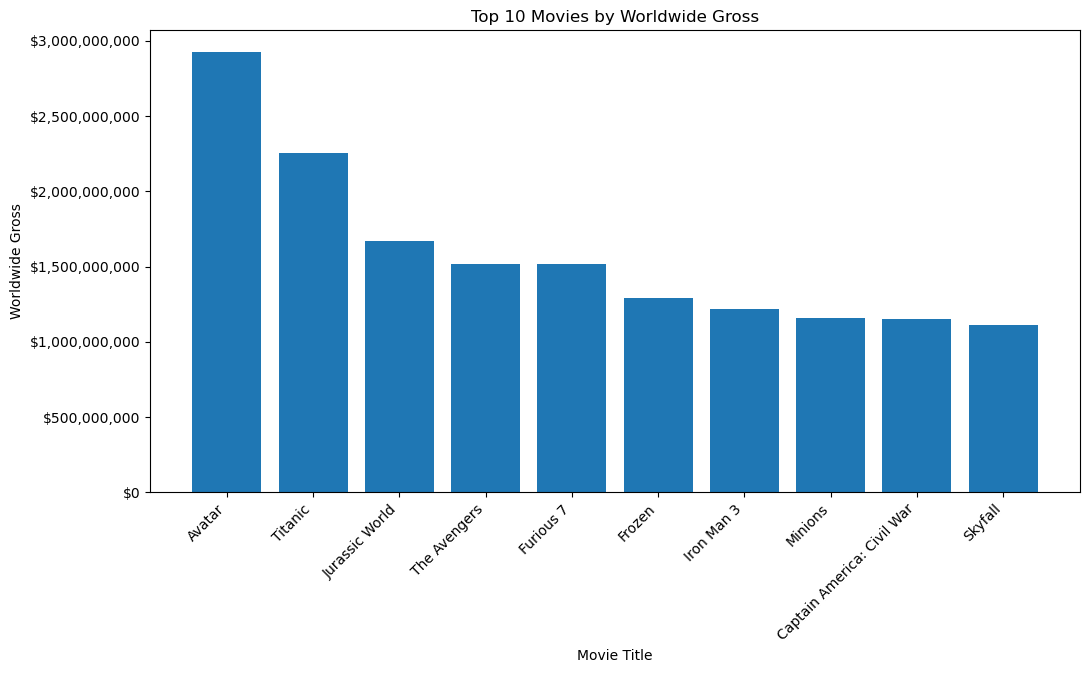

In [10]:
#Convert worldwide gross to numeric values
df_merged['worldwide_gross_clean'] = (
    df_merged['worldwide_gross']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

#Select top 10 movies by worldwide gross
top_gross = df_merged.sort_values(
    by='worldwide_gross_clean',
    ascending=False
).head(10)

#Create bar chart
plt.figure(figsize=(12,6))
plt.bar(top_gross['title'], top_gross['worldwide_gross_clean'])

#Format y-axis as dollar values
formatter = FuncFormatter(lambda x, p: f'${x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

#Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

#Add chart labels and title
plt.xlabel("Movie Title")
plt.ylabel("Worldwide Gross")
plt.title("Top 10 Movies by Worldwide Gross")

#Output
plt.show()

#### Visualization 3: Movie Count by Genre

This visualization examines the number of movies contained within each genre category in the merged dataset. Understanding genre frequency helps identify which types of films are most commonly represented and provides additional context for later profitability analysis.

Output: The horizontal bar chart shows that certain genres appear far more frequently within the dataset than others, indicating uneven genre representation across movies. This suggests that some genres are more commonly produced within the film industry, which may influence overall profitability patterns observed later in the analysis.

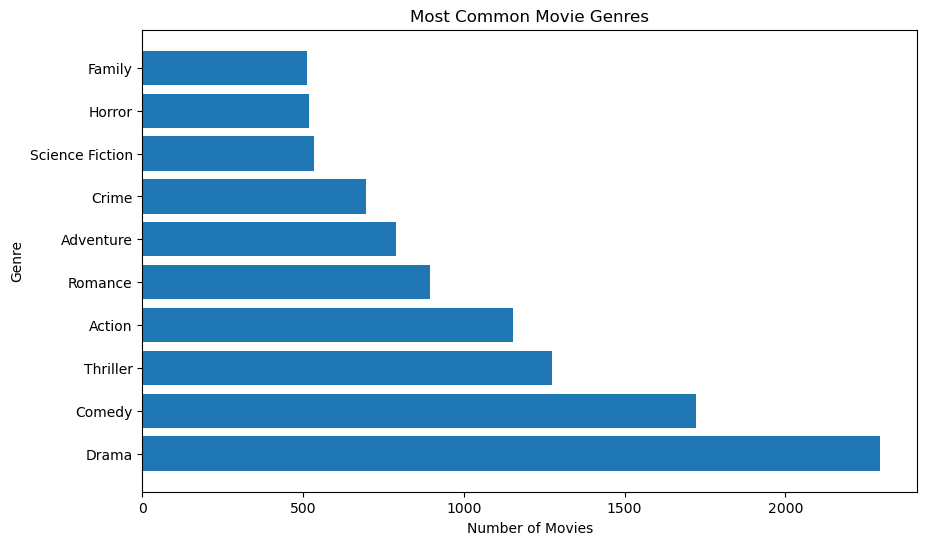

In [11]:
#Split genre values into separate entries
genre_series = df_merged['genres'].dropna().str.split(',')

#Flatten genre list
all_genres = genre_series.explode().str.strip()

#Count genre frequency
genre_counts = all_genres.value_counts().head(10)

#Create horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(genre_counts.index, genre_counts.values)

#Add chart labels and title
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Most Common Movie Genres")

#Output
plt.show()

#### Visualization 4: Average Revenue by Genre

This visualization compares the average movie revenue across different genres using the merged dataset. The goal is to identify whether certain genres tend to generate stronger financial performance than others.

Output: The bar chart shows that some genres achieved noticeably higher average revenues than others. Genres associated with large-scale productions, such as adventure and action films, generally produced stronger average financial performance, while other genres demonstrated lower average revenues. These differences suggest that genre may contribute to profitability outcomes, although substantial variability still exists within each category.

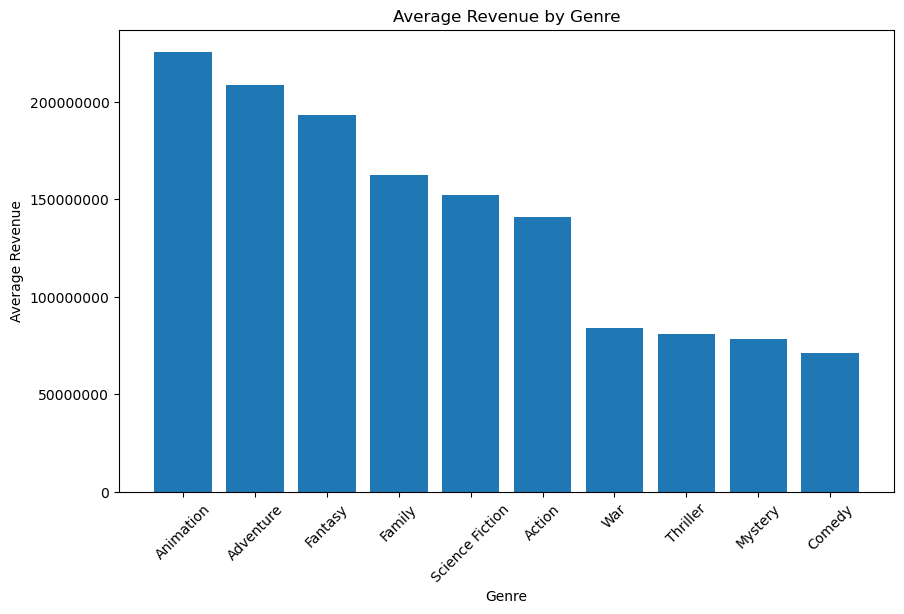

In [12]:
#Create separate rows for each genre
genre_revenue = df_merged[['genres', 'revenue']].dropna()

genre_revenue['genres'] = genre_revenue['genres'].str.split(',')

genre_revenue = genre_revenue.explode('genres')

#Clean genre names
genre_revenue['genres'] = genre_revenue['genres'].str.strip()

#Calculate average revenue by genre
avg_revenue = genre_revenue.groupby('genres')[
    'revenue'
].mean().sort_values(ascending=False).head(10)

#Create bar chart
plt.figure(figsize=(10,6))

plt.bar(
    avg_revenue.index,
    avg_revenue.values
)

#Add chart labels and title
plt.xlabel("Genre")
plt.ylabel("Average Revenue")
plt.title("Average Revenue by Genre")

#Rotate x-axis labels
plt.xticks(rotation=45)

#Format revenue axis
plt.ticklabel_format(style='plain', axis='y')

#Output
plt.show()

#### Visualization 5: Revenue Distribution by Genre

This visualization explores the distribution of movie revenues across genres using a boxplot. Examining revenue distributions provides insight into variability, median performance, and the presence of outliers within each genre category.

Output: The boxplot demonstrates substantial variation in movie revenue across genres. Some genres show higher median revenues and wider revenue ranges, while others display more consistent but lower overall financial performance. Several extreme outliers are also present, reflecting the impact of blockbuster films that generated exceptionally large revenues compared to the majority of movies in the dataset.

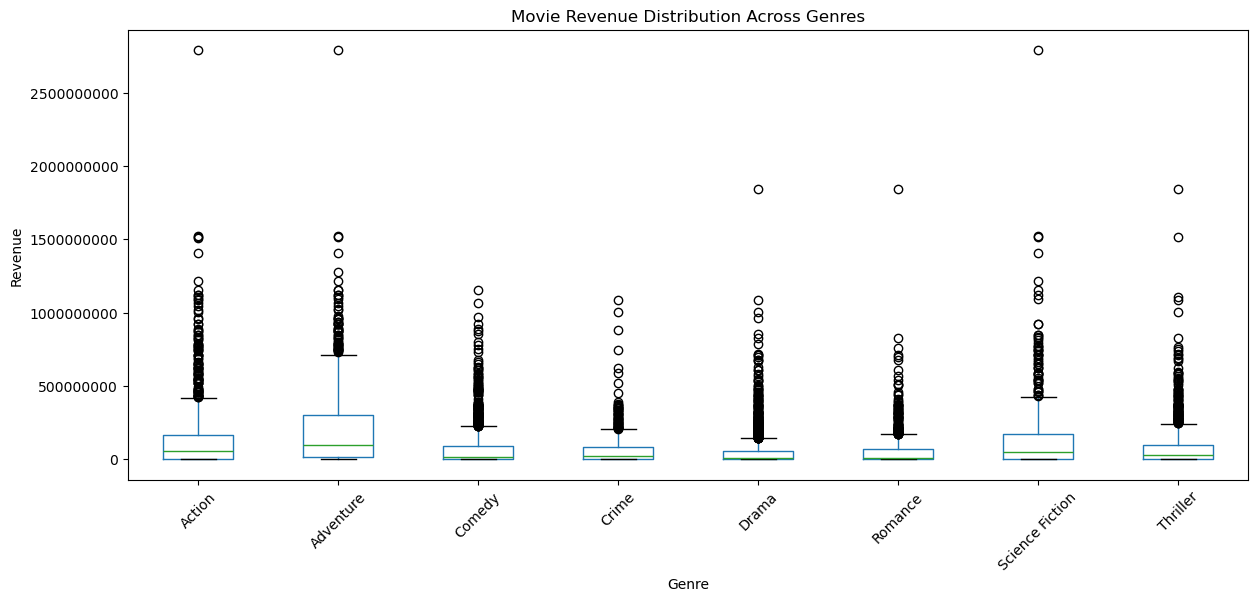

In [13]:
#Create genre revenue dataset
genre_revenue = []

#Loop through genres column
for index, row in df_merged.iterrows():

    if pd.notnull(row['genres']):

        genres = row['genres'].split(',')

        for genre in genres:

            genre_revenue.append({
                'genre': genre.strip(),
                'revenue': row['revenue']
            })

#Convert to dataframe
genre_revenue_df = pd.DataFrame(genre_revenue)

#Get top genres only
top_genres = genre_revenue_df['genre'].value_counts().head(8).index

filtered_genres = genre_revenue_df[
    genre_revenue_df['genre'].isin(top_genres)
]

#Create figure and axis
fig, ax = plt.subplots(figsize=(14,6))

#Create boxplot
filtered_genres.boxplot(
    column='revenue',
    by='genre',
    grid=False,
    rot=45,
    ax=ax
)

#Clean title formatting
plt.suptitle("")
ax.set_title("Movie Revenue Distribution Across Genres")

#Axis labels
ax.set_xlabel("Genre")
ax.set_ylabel("Revenue")

#Format revenue axis
ax.ticklabel_format(style='plain', axis='y')

#Output
plt.show()

## Project Summary and Ethical Considerations

This project focused on integrating and analyzing multiple movie-related datasets to better understand factors associated with movie success and profitability. Data was collected from three primary sources throughout the project, including a Kaggle flat file dataset, TMDb API data, and website data collected from Wikipedia tables containing the highest-grossing films. These datasets were cleaned, transformed, merged using SQL joins, and analyzed using Python visualizations and SQLite.

Several preprocessing and transformation steps were performed throughout the project milestones. These included standardizing column names, handling missing values, converting data types, removing duplicate records, cleaning currency and release year fields, standardizing text formatting, converting nested JSON-like structures into readable formats, and transforming genre identifiers into descriptive labels. Additional integration steps were required to align records across datasets using movie titles and release years as composite matching fields.

One important assumption made throughout the project was that movie titles and release years could be used reliably to connect records across multiple sources. However, slight title variations, alternate naming conventions, remakes, and international releases could still introduce mismatches or incomplete joins. Another assumption involved simplifying genre information and formatting financial fields into standardized formats for easier analysis. While these transformations improved usability, they may also reduce some of the original detail contained within the raw data.

The datasets used in this project were obtained from publicly available and widely used sources, including Kaggle, TMDb, and Wikipedia. TMDb data was retrieved directly through the API, while the website data was collected through web scraping techniques using publicly accessible HTML tables. No personally identifiable or sensitive information was collected or used during the project.

Several ethical considerations still exist within this analysis. Public movie datasets often place heavier focus on high-budget or highly popular films, which can unintentionally underrepresent smaller independent, foreign, or lower-budget productions. This can influence the overall conclusions drawn from the analysis and may not fully reflect the broader film industry as a whole. Additionally, the Wikipedia data used in this project is community-maintained, meaning occasional inaccuracies, inconsistencies, or outdated information may still exist within the dataset.

The transformation and cleaning process itself can also introduce potential bias. Decisions such as removing records with missing values, simplifying movies into primary genre categories, or filtering out invalid financial data were necessary to improve consistency and usability, but these choices may also affect the final analytical results. In some cases, simplifying complex data structures can reduce detail that may still hold analytical value.

To help reduce these concerns, all major transformation and cleaning steps were documented throughout each milestone, and datasets were cross-referenced across multiple sources whenever possible to improve consistency and reliability. Care was also taken to preserve the original meaning of the data while still creating a structured dataset suitable for analysis. Future improvements could include implementing stronger validation techniques, using more advanced fuzzy matching methods during dataset integration, and expanding the project to include a wider range of movie datasets to improve representation across different types of films and audiences.